In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

torch.manual_seed(42)

In [2]:
distances = torch.tensor([
    [1.0], [1.5], [2.0], [2.5], [3.0], [3.5], [4.0], [4.5], [5.0], [5.5],
    [6.0], [6.5], [7.0], [7.5], [8.0], [8.5], [9.0], [9.5], [10.0], [10.5],
    [11.0], [11.5], [12.0], [12.5], [13.0], [13.5], [14.0], [14.5], [15.0], [15.5],
    [16.0], [16.5], [17.0], [17.5], [18.0], [18.5], [19.0], [19.5], [20.0]
], dtype=torch.float32)

# Corresponding delivery times in minutes
times = torch.tensor([
    [6.96], [9.67], [12.11], [14.56], [16.77], [21.7], [26.52], [32.47], [37.15], [42.35],
    [46.1], [52.98], [57.76], [61.29], [66.15], [67.63], [69.45], [71.57], [72.8], [73.88],
    [76.34], [76.38], [78.34], [80.07], [81.86], [84.45], [83.98], [86.55], [88.33], [86.83],
    [89.24], [88.11], [88.16], [91.77], [92.27], [92.13], [90.73], [90.39], [92.98]
], dtype=torch.float32)

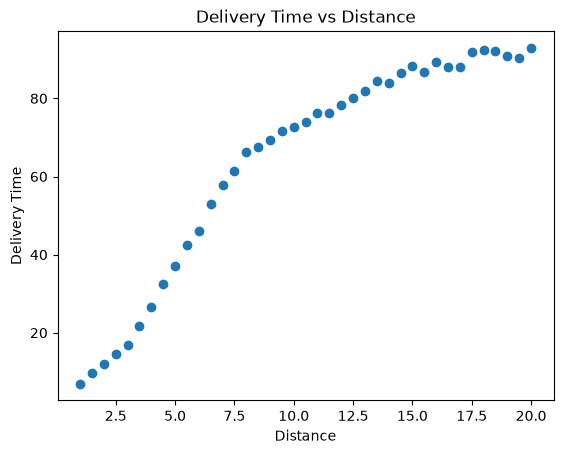

In [3]:
plt.plot(distances, times, 'o')
plt.xlabel('Distance')
plt.ylabel('Delivery Time')
plt.title('Delivery Time vs Distance')
plt.show()

In [4]:
# Normalize the data using z-score normalization
distance_mean = distances.mean()
distance_std = distances.std()
time_mean = times.mean()
time_std = times.std()

distances = (distances - distance_mean) / distance_std
times = (times - time_mean) / time_std

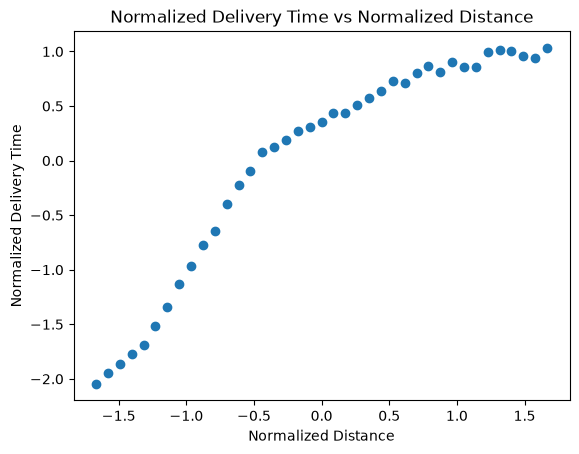

In [5]:
plt.scatter(distances.numpy(), times.numpy())
plt.xlabel('Normalized Distance')   
plt.ylabel('Normalized Delivery Time')
plt.title('Normalized Delivery Time vs Normalized Distance')
plt.show()

In [6]:
# Linear regression with 1 hidden layer (5 neurons) and ReLU activation
model = nn.Sequential(
    nn.Linear(1, 5), # hidden layer with 5 neurons and 1 input feature
    nn.ReLU(), # activation function applied to the hidden layer
    nn.Linear(5, 1) # output layer with 1 output feature
)

In [7]:
loss_function = nn.MSELoss()  # Mean Squared Error loss
optimizer = optim.SGD(model.parameters(), lr=0.01)  # Stochastic Gradient Descent optimizer 

In [8]:
num_epochs = 3000
for epoch in range(num_epochs):
    # Forward pass: Compute predicted y by passing x to the model
    y_pred = model(distances)

    # Compute and print loss
    loss = loss_function(y_pred, times)

    # Zero gradients, perform a backward pass, and update the weights.
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch+1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [100/3000], Loss: 0.3540
Epoch [200/3000], Loss: 0.2415
Epoch [300/3000], Loss: 0.1737
Epoch [400/3000], Loss: 0.1288
Epoch [500/3000], Loss: 0.1026
Epoch [600/3000], Loss: 0.0878
Epoch [700/3000], Loss: 0.0749
Epoch [800/3000], Loss: 0.0607
Epoch [900/3000], Loss: 0.0478
Epoch [1000/3000], Loss: 0.0379
Epoch [1100/3000], Loss: 0.0309
Epoch [1200/3000], Loss: 0.0264
Epoch [1300/3000], Loss: 0.0233
Epoch [1400/3000], Loss: 0.0212
Epoch [1500/3000], Loss: 0.0198
Epoch [1600/3000], Loss: 0.0185
Epoch [1700/3000], Loss: 0.0173
Epoch [1800/3000], Loss: 0.0163
Epoch [1900/3000], Loss: 0.0155
Epoch [2000/3000], Loss: 0.0146
Epoch [2100/3000], Loss: 0.0138
Epoch [2200/3000], Loss: 0.0131
Epoch [2300/3000], Loss: 0.0124
Epoch [2400/3000], Loss: 0.0116
Epoch [2500/3000], Loss: 0.0109
Epoch [2600/3000], Loss: 0.0103
Epoch [2700/3000], Loss: 0.0097
Epoch [2800/3000], Loss: 0.0091
Epoch [2900/3000], Loss: 0.0085
Epoch [3000/3000], Loss: 0.0080


In [9]:
# model parameters
layer1 = model[0]  # Access the first layer of the model
weights = layer1.weight.data.numpy()
bias = layer1.bias.data.numpy()

print(f'Weights: {weights}, Bias: {bias}')

Weights: [[ 0.5092373 ]
 [ 1.2072881 ]
 [-0.74493384]
 [ 0.82681495]
 [-0.21910357]], Bias: [ 0.80829453  0.17241919  0.42664677  1.3230464  -0.73362815]


In [10]:
# model[1] contain the activation function (ReLU), so we can skip it and access the second layer directly
layer2 = model[2] # Access the second layer of the model
weights2 = layer2.weight.data.numpy()
bias2 = layer2.bias.data.numpy()

print(f'Weights of second layer: {weights2}, Bias of second layer: {bias2}')

Weights of second layer: [[ 0.6617853  -0.7540536  -0.66907656  0.90429103  0.21564108]], Bias of second layer: [-0.89670175]


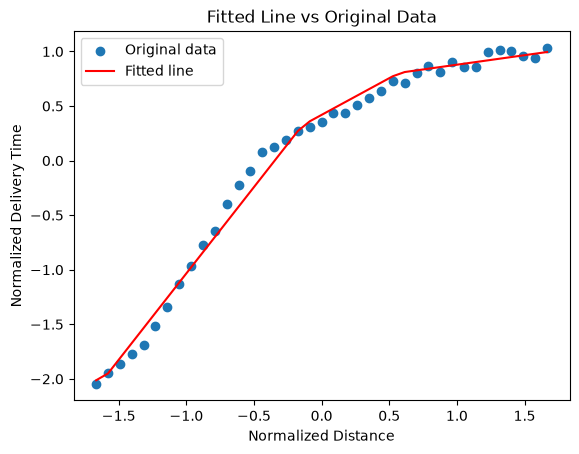

In [11]:
with torch.no_grad():
    predicted_times = model(distances)

plt.scatter(distances.numpy(), times.numpy(), label='Original data')
plt.plot(distances.numpy(), predicted_times.numpy(), label='Fitted line', color='red')
plt.xlabel('Normalized Distance')   
plt.ylabel('Normalized Delivery Time')
plt.title('Fitted Line vs Original Data')
plt.legend()

In [14]:
test_point = torch.tensor([[5.0]], dtype=torch.float32)  # Test point (distance = 5.0)

with torch.no_grad():
    normalized_test_point = (test_point - distance_mean) / distance_std  # Normalize the test point
    predicted_time = model(normalized_test_point)  # Predict the delivery time for the test point
    denormalized_predicted_time = predicted_time * time_std + time_mean  # Denormalize the predicted time

    if denormalized_predicted_time.item() > 45:
        print("\nDecision: Do NOT promise the delivery in under 45 minutes.")
    else:
        if test_point <= 3:
            print(f"\nDecision: Yes, delivery is possible. Since the distance is {test_point.item()} miles (<= 3 miles), use a bike.")
        else:
            print(f"\nDecision: Yes, delivery is possible. Since the distance is {test_point.item()} miles (> 3 miles), use a car.")



Decision: Yes, delivery is possible. Since the distance is 5.0 miles (> 3 miles), use a car.


In [18]:
torch.cuda.is_available()

False